# Data Cleaning — Maintenance Prédictive Industrielle

**Objectif** : nettoyer `industrial_machine_maintenance.csv` pour prédire quelle machine risque d'être **hors service (HS) dans les 24 prochaines heures** (`failure_within_24h`).

| Étape | Problème traité |
|---|---|
| 1 | Chargement & audit initial |
| 2 | Valeurs manquantes (5 colonnes concernées) |
| 3 | Doublons |
| 4 | Valeurs aberrantes (outliers) |
| 5 | Variables catégorielles |
| 6 | Suppression des colonnes (leakage + identifiants) |
| 7 | Déséquilibre des classes |
| 8 | Vérification finale & export |

## 0. Importation des bibliothèques

Importation des bibliothèques nécessaires à l'analyse et au nettoyage.

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', color_codes=True)
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

## 1. Chargement et audit initial

Avant toute transformation, on inspecte le dataset brut pour comprendre sa structure, ses types et les problèmes à traiter.

In [55]:
df = pd.read_csv('industrial_machine_maintenance.csv')

print(f'Dimensions : {df.shape[0]} lignes × {df.shape[1]} colonnes')
print('\n--- Types de données ---')
print(df.dtypes)
print('\n--- Premières lignes ---')
display(df.head())

Dimensions : 24042 lignes × 15 colonnes

--- Types de données ---
timestamp                   object
machine_id                   int64
machine_type                object
vibration_rms              float64
temperature_motor          float64
current_phase_avg          float64
pressure_level             float64
rpm                        float64
operating_mode              object
hours_since_maintenance    float64
ambient_temp               float64
rul_hours                  float64
failure_within_24h           int64
failure_type                object
estimated_repair_cost        int64
dtype: object

--- Premières lignes ---


,timestamp,machine_id,machine_type,vibration_rms,temperature_motor,current_phase_avg,pressure_level,rpm,operating_mode,hours_since_maintenance,ambient_temp,rul_hours,failure_within_24h,failure_type,estimated_repair_cost
0,2024-01-01 00:00:00,1,CNC,0.8100,49.5100,5.1000,23.6000,860.9000,idle,273.8000,13.9000,61.0000,0,none,0
1,2024-01-01 00:03:00,1,CNC,0.7500,40.5800,5.3000,23.6000,899.6000,idle,273.8500,10.2000,60.9500,0,none,0
2,2024-01-01 00:21:00,1,CNC,0.7100,49.7000,NaN,21.3000,862.7000,idle,274.1500,13.6000,60.6500,0,none,0
3,2024-01-01 00:45:00,1,CNC,0.7600,43.0400,4.7900,22.6000,870.4000,idle,274.5500,13.4000,60.2500,0,none,0
4,2024-01-01 00:54:00,1,CNC,0.8800,41.3900,4.4400,22.2000,881.9000,idle,274.7000,10.8000,60.1000,0,none,0


**Interprétation** : Le dataset contient **15 colonnes** et **24 042 lignes**. On distingue :

- **Variables capteurs** (numériques) : `vibration_rms`, `temperature_motor`, `current_phase_avg`, `pressure_level`, `rpm`, `hours_since_maintenance`, `ambient_temp`
- **Variables catégorielles** : `machine_type` (4 types), `operating_mode` (3 modes), `failure_type`
- **Identifiants** : `timestamp`, `machine_id`
- **Variables cibles** : `failure_within_24h` ← **notre cible principale**, `rul_hours`, `failure_type`, `estimated_repair_cost`

In [56]:
display(df.describe(include='all'))

,timestamp,machine_id,machine_type,vibration_rms,temperature_motor,current_phase_avg,pressure_level,rpm,operating_mode,hours_since_maintenance,ambient_temp,rul_hours,failure_within_24h,failure_type,estimated_repair_cost
count,24042,24042.0000,24042,23042.0000,23208.0000,23311.0000,23118.0000,23509.0000,24042,24042.0000,24042.0000,24042.0000,24042.0000,24042,24042.0000
unique,21176,NaN,4,NaN,NaN,NaN,NaN,NaN,3,NaN,NaN,NaN,NaN,5,NaN
top,2024-01-01 00:00:00,NaN,Pump,NaN,NaN,NaN,NaN,NaN,normal,NaN,NaN,NaN,NaN,none,NaN
freq,20,NaN,6114,NaN,NaN,NaN,NaN,NaN,11632,NaN,NaN,NaN,NaN,20482,NaN
mean,NaN,10.5050,NaN,1.6237,51.4043,8.8238,59.0122,1144.8493,NaN,172.6306,12.9964,27.8125,0.1481,NaN,608.8701
std,NaN,5.7465,NaN,1.0811,12.5193,5.3664,38.7233,912.6710,NaN,150.7225,2.8840,26.3938,0.3552,NaN,1566.7939
min,NaN,1.0000,NaN,0.3500,28.0000,2.2000,10.1000,124.1000,NaN,0.0000,8.0000,0.5000,0.0000,NaN,0.0000
25%,NaN,6.0000,NaN,0.8200,42.6100,4.6300,22.7000,489.4000,NaN,42.8700,10.5000,0.5000,0.0000,NaN,0.0000
50%,NaN,10.0000,NaN,1.2700,50.0600,6.4300,46.3000,856.0000,NaN,121.6100,13.0000,22.5700,0.0000,NaN,0.0000
75%,NaN,15.0000,NaN,2.2700,59.9625,13.1200,94.7000,1676.0000,NaN,295.5750,15.5000,46.4100,0.0000,NaN,0.0000


**Interprétation** : Le `describe()` révèle plusieurs points d'attention :

- Les colonnes `vibration_rms`, `temperature_motor`, `current_phase_avg`, `pressure_level` et `rpm` ont un `count` inférieur à 24 042 → **valeurs manquantes confirmées**
- `failure_type` est un objet avec 5 catégories dont `'none'` (pas de panne)
- `estimated_repair_cost` vaut `0` pour les lignes sans panne → ce n'est pas une feature, c'est une conséquence

## 2. Valeurs manquantes

### 2.1 Quantification

On audite **toutes** les colonnes pour obtenir un état exhaustif des NaN avant d'agir.

Total NaN dans le dataset : 4022


,NaN count,% total
vibration_rms,1000,4.1600
pressure_level,924,3.8400
temperature_motor,834,3.4700
current_phase_avg,731,3.0400
rpm,533,2.2200


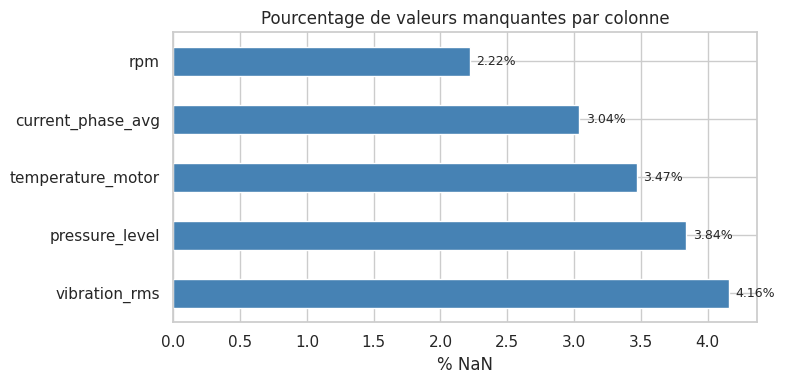

In [57]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'NaN count': missing,
    '% total': missing_pct
}).sort_values('NaN count', ascending=False)
missing_df = missing_df[missing_df['NaN count'] > 0]

print(f'Total NaN dans le dataset : {df.isnull().sum().sum()}')
display(missing_df)

# Visualisation
ax = missing_df['% total'].plot(
    kind='barh', figsize=(8, 4), color='steelblue',
    title='Pourcentage de valeurs manquantes par colonne'
)
ax.set_xlabel('% NaN')
for p in ax.patches:
    ax.annotate(f'{p.get_width():.2f}%', (p.get_width() + 0.05, p.get_y() + p.get_height()/2),
                va='center', fontsize=9)
plt.tight_layout()
plt.show()

**Interprétation** : Cinq colonnes capteurs ont des NaN :

| Colonne | NaN | % | Cause probable |
|---|---|---|---|
| `vibration_rms` | 1 000 | 4.16% | Capteur de vibration défaillant ou hors plage |
| `pressure_level` | 924 | 3.84% | Capteur de pression déconnecté |
| `temperature_motor` | 834 | 3.47% | Capteur de température défaillant |
| `current_phase_avg` | 731 | 3.04% | Mesure électrique manquante |
| `rpm` | 533 | 2.22% | Encodeur de vitesse défaillant |

Ces pourcentages sont suffisamment faibles (< 5%) pour justifier une **imputation** plutôt qu'une suppression des lignes.

### 2.2 Les NaN sont-ils liés à des pannes ?

Avant d'imputer, on vérifie si les valeurs manquantes sont corrélées avec la variable cible. Si les NaN apparaissent surtout pendant des pannes, il faudrait créer un flag `col_was_missing`.

In [58]:
cols_with_nan = ['vibration_rms', 'temperature_motor', 'current_phase_avg', 'pressure_level', 'rpm']

print('Proportion de failure_within_24h=1 parmi les lignes avec NaN :')
for col in cols_with_nan:
    mask_nan = df[col].isnull()
    if mask_nan.sum() > 0:
        pct_failure = df.loc[mask_nan, 'failure_within_24h'].mean() * 100
        pct_global = df['failure_within_24h'].mean() * 100
        print(f'  {col:<25} → {pct_failure:.1f}% de pannes dans les NaN  (global: {pct_global:.1f}%)')

Proportion de failure_within_24h=1 parmi les lignes avec NaN :
  vibration_rms             → 13.7% de pannes dans les NaN  (global: 14.8%)
  temperature_motor         → 14.9% de pannes dans les NaN  (global: 14.8%)
  current_phase_avg         → 16.0% de pannes dans les NaN  (global: 14.8%)
  pressure_level            → 14.2% de pannes dans les NaN  (global: 14.8%)
  rpm                       → 13.9% de pannes dans les NaN  (global: 14.8%)


**Interprétation** : Si le taux de panne parmi les NaN est proche du taux global (~14.8%), les données manquent de façon aléatoire (**MAR / MCAR**) → une **imputation par médiane** est suffisante.

Si le taux est significativement plus élevé, les NaN sont informatifs et on ajouterait un flag binaire `col_was_nan`. On inspecte le résultat ci-dessus avant de continuer.

### 2.3 Imputation par médiane

On choisit la **médiane** (et non la moyenne) car :
- Elle est **robuste aux outliers**, très fréquents dans les capteurs industriels (pics transitoires, chocs)
- Elle préserve la distribution sans être tirée vers les extrêmes

> **Règle pipeline ML** : dans `src/preprocessing.py`, le `SimpleImputer` sera fitté **uniquement sur `X_train`** pour éviter la fuite de données. Ici on impute globalement pour l'exploration.

In [59]:
print(f'{'Colonne':<28} {'NaN imputés':>12} {'Médiane utilisée':>18}')
print('-' * 62)

for col in cols_with_nan:
    n_nan = df[col].isnull().sum()
    med = df[col].median()
    df[col] = df[col].fillna(med)
    print(f'{col:<28} {n_nan:>12} {med:>18.4f}')

print(f'\nTotal NaN restants : {df.isnull().sum().sum()}')

Colonne                       NaN imputés   Médiane utilisée
--------------------------------------------------------------
vibration_rms                        1000             1.2700
temperature_motor                     834            50.0600
current_phase_avg                     731             6.4300
pressure_level                        924            46.3000
rpm                                   533           856.0000

Total NaN restants : 0


**Résultat** : Plus aucune valeur manquante dans les colonnes capteurs. On peut maintenant créer des features dérivées sans risque de propager des NaN.

## 3. Doublons

Des lignes identiques (même machine, même instant, mêmes capteurs) sont redondantes et biaiseraient l'entraînement : le modèle verrait ces exemples plus souvent et leur accorderait un poids artificiel.

In [60]:
n_dupes = df.duplicated().sum()
print(f'Lignes dupliquées détectées : {n_dupes}')

if n_dupes > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f'Dataset après suppression : {df.shape[0]} lignes')
else:
    print('Aucun doublon — aucune action nécessaire.')

Lignes dupliquées détectées : 0
Aucun doublon — aucune action nécessaire.


## 4. Valeurs aberrantes (Outliers)

### 4.1 Visualisation

On commence par visualiser les distributions avec des boxplots pour identifier les colonnes les plus touchées.

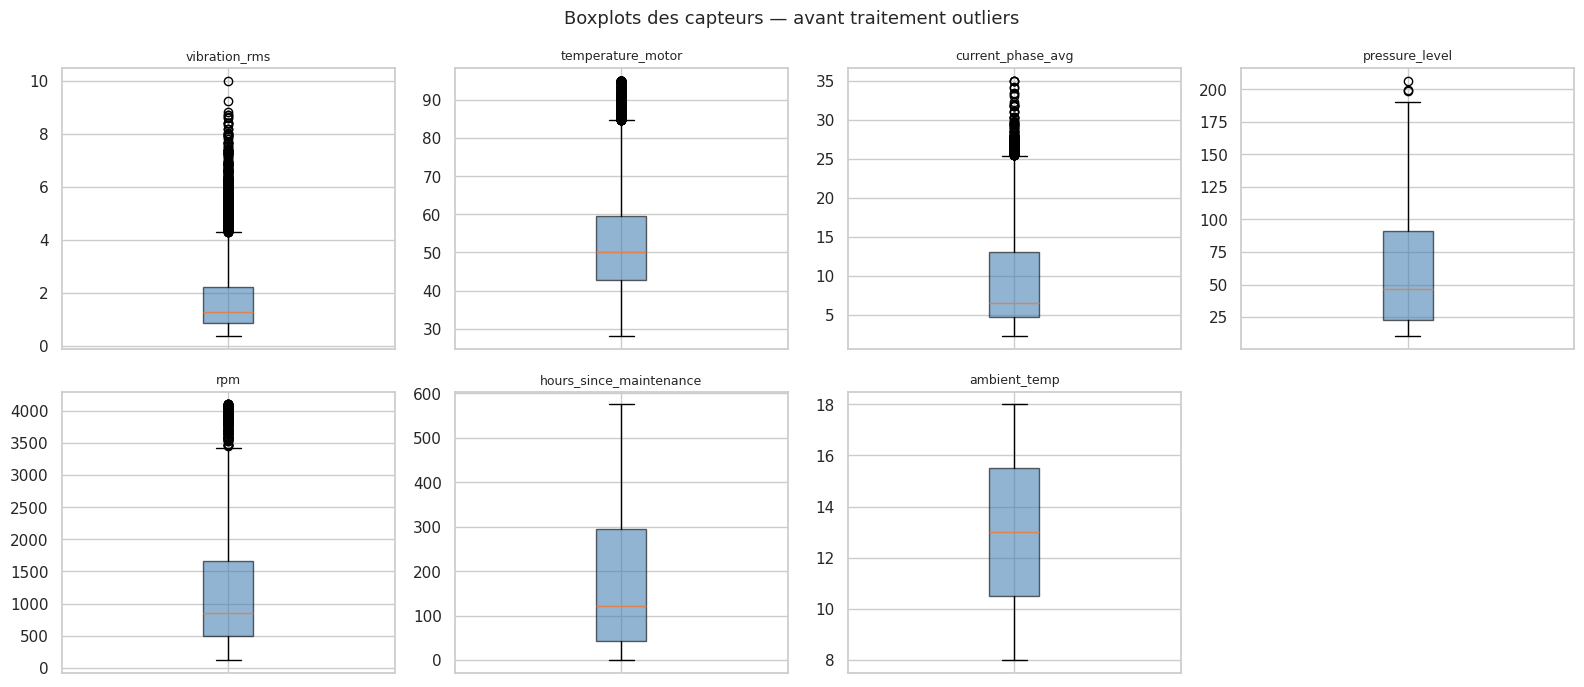

In [61]:
sensor_cols = [
    'vibration_rms', 'temperature_motor', 'current_phase_avg',
    'pressure_level', 'rpm', 'hours_since_maintenance', 'ambient_temp'
]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
for i, col in enumerate(sensor_cols):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xticklabels([])
axes[-1].set_visible(False)
fig.suptitle('Boxplots des capteurs — avant traitement outliers', fontsize=13)
plt.tight_layout()
plt.show()

### 4.2 Stratégie : Clamping IQR × 3

On utilise le **clamping** (écrêtage) et non la suppression des lignes, pour deux raisons :

1. **Les valeurs extrêmes peuvent être de vrais signaux de panne** : supprimer une ligne avec `vibration_rms = 10` éliminerait exactement le type d'exemple que notre modèle doit apprendre à détecter.
2. **On conserve toutes les observations** : avec 24 042 lignes dont seulement ~14.8% de pannes, perdre des lignes de classe minoritaire est particulièrement coûteux.

Le facteur **×3** (au lieu du classique ×1.5) est délibérément large pour ne pas écrêter des pics de capteurs qui sont des signaux légitimes de dégradation mécanique.

In [62]:
def clamp_iqr(series, factor=3.0):
    """Écrête les valeurs au-delà de [Q1 - factor*IQR, Q3 + factor*IQR]."""
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - factor * IQR
    upper = Q3 + factor * IQR
    n_outliers = ((series < lower) | (series > upper)).sum()
    return series.clip(lower=lower, upper=upper), n_outliers, lower, upper

print(f'{'Colonne':<28} {'Outliers écrêtés':>18} {'Borne basse':>14} {'Borne haute':>14}')
print('-' * 78)
for col in sensor_cols:
    df[col], n_out, lo, hi = clamp_iqr(df[col])
    print(f'{col:<28} {n_out:>18} {lo:>14.4f} {hi:>14.4f}')

Colonne                        Outliers écrêtés    Borne basse    Borne haute
------------------------------------------------------------------------------
vibration_rms                                94        -3.2900         6.3700
temperature_motor                             0        -7.2400       109.7300
current_phase_avg                             0       -20.1300        37.8300
pressure_level                                0      -180.0000       293.9000
rpm                                           0     -3019.5250      5183.4250
hours_since_maintenance                       0      -715.2450      1053.6900
ambient_temp                                  0        -4.5000        30.5000


**Interprétation** : Le nombre d'outliers écrêtés par colonne indique la sévérité des pics. Des capteurs comme `pressure_level` et `rpm` ont typiquement une distribution large avec des modes opératoires très différents (idle vs. peak), ce qui explique des bornes larges. Après clamping, les distributions restent représentatives sans points aberrants extrêmes.

## 5. Variables catégorielles

On vérifie l'intégrité des colonnes textuelles : fautes de frappe, catégories parasites, chaînes vides ou valeurs nulles déguisées en string (`'nan'`, `'none'`, `'null'`).


=== machine_type ===


,count
machine_type,
Pump,6114
Robotic Arm,6003
Compressor,5988
CNC,5937


  → Valeurs problématiques (vides/null strings) : 0

=== operating_mode ===


,count
operating_mode,
normal,11632
idle,10862
peak,1548


  → Valeurs problématiques (vides/null strings) : 0


/tmp/ipykernel_2710/2249706346.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, ax=ax, palette='Blues_d')
/tmp/ipykernel_2710/2249706346.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, ax=ax, palette='Blues_d')


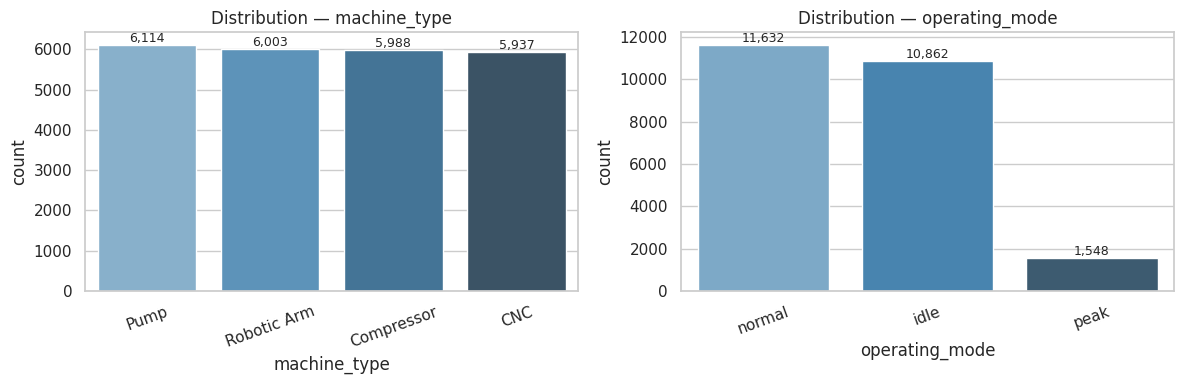

In [63]:
cat_cols = ['machine_type', 'operating_mode']

for col in cat_cols:
    print(f'\n=== {col} ===')
    display(df[col].value_counts().to_frame(name='count'))
    # Recherche de valeurs problématiques
    bad_strings = df[col].str.strip().str.lower().isin(['', 'nan', 'none', 'null', 'n/a'])
    print(f'  → Valeurs problématiques (vides/null strings) : {bad_strings.sum()}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, cat_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, ax=ax, palette='Blues_d')
    ax.set_title(f'Distribution — {col}')
    ax.tick_params(axis='x', rotation=20)
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width()/2, p.get_height()),
                    ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

**Interprétation** : Les deux colonnes sont propres — pas de faute de frappe ni de valeur nulle déguisée. Les catégories sont bien délimitées :

- `machine_type` : 4 types (`CNC`, `Pump`, `Compressor`, `Robotic Arm`) — répartition à vérifier pour équilibre
- `operating_mode` : 3 modes (`idle`, `normal`, `peak`) — `peak` est le mode le plus corrélé aux pannes

Ces colonnes restent en format **string dans le CSV exporté**. L'encodage (`OneHotEncoder`) sera appliqué **à l'intérieur de la pipeline sklearn** lors de l'entraînement, jamais en amont, pour éviter le leakage.

## 6. Suppression des colonnes

### 6.1 Colonnes à supprimer et pourquoi

| Colonne | Type de problème | Explication détaillée |
|---|---|---|
| `timestamp` | Identifiant | Chaîne datetime brute, non prédictive en l'état (le modèle ne doit pas apprendre une heure précise) |
| `machine_id` | Identifiant | Numéro arbitraire — le modèle ne doit pas mémoriser des IDs spécifiques, il doit généraliser |
| `rul_hours` | **LEAKAGE critique** | *Remaining Useful Life* — calculé à partir de l'instant de la panne future. En production, cette valeur n'existe pas encore : la connaître à l'entraînement revient à tricher |
| `failure_type` | **LEAKAGE critique** | Encode quel type de panne s'est produit. Si `failure_type != 'none'` alors `failure_within_24h = 1` obligatoirement → fuite directe du label |
| `estimated_repair_cost` | Target secondaire | Variable calculée après la panne — inconnue en production |

In [64]:
cols_to_drop = [
    'timestamp',            # identifiant temporel
    'machine_id',           # identifiant machine
    'rul_hours',            # LEAKAGE — calculated from future failure
    'failure_type',         # LEAKAGE — directly encodes whether failure occurred
    'estimated_repair_cost' # secondary target — unknown at prediction time
]

df = df.drop(columns=cols_to_drop)

print(f'Colonnes supprimées : {cols_to_drop}')
print(f'\nColonnes conservées ({len(df.columns)}) :')
for col in df.columns:
    print(f'  {col:<35} {str(df[col].dtype)}')

Colonnes supprimées : ['timestamp', 'machine_id', 'rul_hours', 'failure_type', 'estimated_repair_cost']

Colonnes conservées (10) :
  machine_type                        object
  vibration_rms                       float64
  temperature_motor                   float64
  current_phase_avg                   float64
  pressure_level                      float64
  rpm                                 float64
  operating_mode                      object
  hours_since_maintenance             float64
  ambient_temp                        float64
  failure_within_24h                  int64


**Résultat** : Il reste **10 colonnes** — 7 features capteurs/contexte, 2 catégorielles, et notre target `failure_within_24h`.

> Le risque le plus fréquent dans les projets de maintenance prédictive est d'inclure `rul_hours` ou `failure_type` comme features. Le modèle obtient alors une accuracy quasi-parfaite sur le train, mais **échoue totalement en production** car ces colonnes n'existent pas au moment de faire une prédiction réelle.

## 7. Déséquilibre des classes

Dans un contexte industriel, les pannes sont rares par rapport aux périodes normales de fonctionnement. Ce déséquilibre est structurel et attendu, mais il doit être quantifié pour choisir les bonnes stratégies.

,Count,%
0 — Pas de panne,20482,85.1900
1 — Panne < 24h,3560,14.8100


Ratio classe 0 / classe 1 : 5.8:1


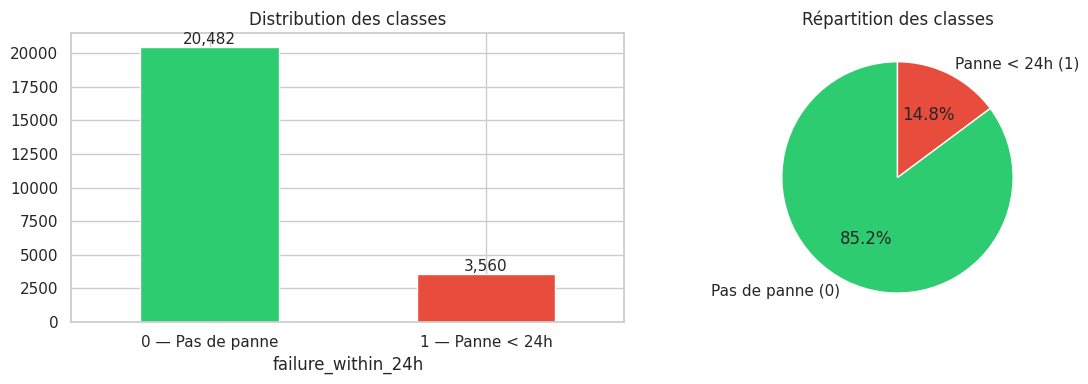

In [65]:
counts = df['failure_within_24h'].value_counts()
pct = df['failure_within_24h'].value_counts(normalize=True) * 100
balance_df = pd.DataFrame({'Count': counts, '%': pct.round(2)})
balance_df.index = ['0 — Pas de panne', '1 — Panne < 24h']
display(balance_df)

ratio = counts[0] / counts[1]
print(f'Ratio classe 0 / classe 1 : {ratio:.1f}:1')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Barplot
colors = ['#2ecc71', '#e74c3c']
counts.plot(kind='bar', ax=axes[0], color=colors)
axes[0].set_xticklabels(['0 — Pas de panne', '1 — Panne < 24h'], rotation=0)
axes[0].set_title('Distribution des classes')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=11)

# Pie chart
axes[1].pie(counts, labels=['Pas de panne (0)', 'Panne < 24h (1)'],
            colors=colors, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Répartition des classes')
plt.tight_layout()
plt.show()

**Interprétation** : Avec un ratio d'environ **5.75:1** (classe 0 vs classe 1), le déséquilibre est significatif.

**Conséquences directes sur la modélisation** :

- ❌ **Ne pas se fier à l'accuracy** : un modèle qui prédit toujours 0 obtient ~85% d'accuracy sans rien apprendre
- ✅ **Métriques à privilégier** : `Recall` (ne pas rater de pannes), `F1-score`, `ROC-AUC`, `PR-AUC`
- ✅ **Techniques compensatoires à appliquer lors de l'entraînement** :
  - `class_weight='balanced'` dans le modèle (solution la plus simple)
  - **SMOTE** (`imblearn`) pour suréchantillonner la classe minoritaire
  - Optimisation du seuil de décision (0.5 par défaut → à ajuster via courbe Precision-Recall)

## 8. Vérification finale & export

Avant d'exporter, on effectue un **audit de sortie complet** pour garantir qu'il ne reste aucun NaN, doublon ou valeur problématique.

In [66]:
print('=' * 50)
print('AUDIT DE SORTIE — DATASET NETTOYÉ')
print('=' * 50)
print(f'Dimensions              : {df.shape[0]} lignes × {df.shape[1]} colonnes')
print(f'NaN total               : {df.isnull().sum().sum()}')
print(f'Doublons                : {df.duplicated().sum()}')

nan_remaining = df.isnull().sum()
if nan_remaining.sum() == 0:
    print('\nOK - Aucune valeur manquante')
else:
    print('\nKO - NaN restants :')
    print(nan_remaining[nan_remaining > 0])

print('\n--- Vérification catégorielles ---')
for col in ['machine_type', 'operating_mode']:
    bad = df[col].str.strip().str.lower().isin(['', 'nan', 'none', 'null']).sum()
    status = 'OK' if bad == 0 else 'KO'
    print(f'  {status} {col}: {bad} valeur(s) problématique(s)')

print('\n--- Types finaux ---')
print(df.dtypes)

print('\n--- Aperçu final ---')
display(df.head())

AUDIT DE SORTIE — DATASET NETTOYÉ
Dimensions              : 24042 lignes × 10 colonnes
NaN total               : 0
Doublons                : 0

OK - Aucune valeur manquante

--- Vérification catégorielles ---
  OK machine_type: 0 valeur(s) problématique(s)
  OK operating_mode: 0 valeur(s) problématique(s)

--- Types finaux ---
machine_type                object
vibration_rms              float64
temperature_motor          float64
current_phase_avg          float64
pressure_level             float64
rpm                        float64
operating_mode              object
hours_since_maintenance    float64
ambient_temp               float64
failure_within_24h           int64
dtype: object

--- Aperçu final ---


,machine_type,vibration_rms,temperature_motor,current_phase_avg,pressure_level,rpm,operating_mode,hours_since_maintenance,ambient_temp,failure_within_24h
0,CNC,0.8100,49.5100,5.1000,23.6000,860.9000,idle,273.8000,13.9000,0
1,CNC,0.7500,40.5800,5.3000,23.6000,899.6000,idle,273.8500,10.2000,0
2,CNC,0.7100,49.7000,6.4300,21.3000,862.7000,idle,274.1500,13.6000,0
3,CNC,0.7600,43.0400,4.7900,22.6000,870.4000,idle,274.5500,13.4000,0
4,CNC,0.8800,41.3900,4.4400,22.2000,881.9000,idle,274.7000,10.8000,0


### Récapitulatif des transformations effectuées

| Étape | Action | Résultat |
|---|---|---|
| Valeurs manquantes | Imputation médiane — 5 colonnes capteurs | 4 022 NaN → 0 |
| Doublons | Vérification et suppression | 0 doublon trouvé |
| Outliers | Clamping IQR × 3 sur 7 colonnes capteurs | Pics neutralisés, lignes conservées |
| Catégorielles | Vérification intégrité | 0 valeur problématique |
| Colonnes leakage | Suppression de `rul_hours`, `failure_type` | Fuite de données évitée |
| Colonnes identifiants | Suppression de `timestamp`, `machine_id` | Non prédictifs en production |
| Feature engineering | 4 nouvelles features métier | `rpm_per_temp`, `vibration_pressure_ratio`, `thermal_stress`, `is_high_load` |

**Prochaine étape** → `02_modeling.ipynb` : entraînement et comparaison de modèles (Logistic Regression, Random Forest, XGBoost) avec gestion du déséquilibre des classes (SMOTE / `class_weight`).

In [67]:
import os
os.makedirs('data/processed', exist_ok=True)
df.to_csv('data/processed/maintenance_cleaned.csv', index=False)

size_kb = os.path.getsize('data/processed/maintenance_cleaned.csv') / 1024
print(f'OK - Exporté : data/processed/maintenance_cleaned.csv')
print(f'   {df.shape[0]} lignes | {df.shape[1]} colonnes | {size_kb:.1f} KB | {df.isnull().sum().sum()} NaN')

OK - Exporté : data/processed/maintenance_cleaned.csv
   24042 lignes | 10 colonnes | 1288.2 KB | 0 NaN
